# Notebook 2: Metadatos Dicom
Este notebook contiene un análisis exploratorio para los metadatos de las imagenes correspondientes a los scans de cada uno de los pacientes, es decir, de su columna cervical. Vale la pena mencionar que cada carpeta corresponde a un scan de columna cervical y esta contiene imagenes 2D que recrean el volumen scaneado de la columna cervical.

*Nota: Este notebook debe correrse en el editor de kaggle para poder acceder a los datos sin tener la necesidad de descargarlos.*

## 0. Configuración

### Librerías

In [1]:
import os
import pandas as pd
import numpy as np
import pydicom
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

## 1. Preprocesamiento

In [2]:
# Rutas en Kaggle
image_dir = "/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection/train_images"
patient_folders = os.listdir(image_dir)

metadata_list = []

# tqdm muestra una barra de progreso para saber cuánto tardará el proceso
for uid in tqdm(patient_folders, desc="Extrayendo metadata DICOM"):
    patient_path = os.path.join(image_dir, uid)
    
    # Listar todos los archivos DICOM de este paciente
    try:
        slices = os.listdir(patient_path)
    except FileNotFoundError:
        continue
        
    n_slices = len(slices)
    if n_slices == 0:
        continue
        
    # Ruta al primer corte de la tomografía
    first_slice_path = os.path.join(patient_path, slices[0])
    
    try:
        # CRÍTICO: stop_before_pixels=True lee solo los metadatos y evita cargar la imagen 3D a la RAM
        dicom_hdr = pydicom.dcmread(first_slice_path, stop_before_pixels=True)
        
        # Extracción segura con getattr() ya que no todos los hospitales usan los mismos tags
        slice_thickness = getattr(dicom_hdr, 'SliceThickness', np.nan)
        
        # El Pixel Spacing usualmente es una tupla (espaciado en X, espaciado en Y)
        pixel_spacing = getattr(dicom_hdr, 'PixelSpacing', [np.nan, np.nan])
        pixel_spacing_val = pixel_spacing[0] if isinstance(pixel_spacing, (pydicom.multival.MultiValue, list)) else np.nan
        
        manufacturer = getattr(dicom_hdr, 'Manufacturer', 'Desconocido')
        patient_sex = getattr(dicom_hdr, 'PatientSex', 'Desconocido')
        
        # El kernel de reconstrucción a veces viene como lista
        kernel = getattr(dicom_hdr, 'ConvolutionKernel', 'Desconocido')
        if isinstance(kernel, pydicom.multival.MultiValue):
            kernel = "_".join(kernel)
            
        metadata_list.append({
            'StudyInstanceUID': uid,
            'n_slices': n_slices,
            'slice_thickness': float(slice_thickness),
            'pixel_spacing': float(pixel_spacing_val),
            'manufacturer': str(manufacturer).strip(),
            'patient_sex': str(patient_sex).strip(),
            'kernel': str(kernel).strip()
        })
        
    except Exception as e:
        print(f"Error leyendo DICOM del paciente {uid}: {e}")

# Construir el DataFrame
df_meta = pd.DataFrame(metadata_list)

# Calcular z_extent (Volumen físico cubierto por el escáner)
df_meta['z_extent'] = df_meta['n_slices'] * df_meta['slice_thickness']

# Guardar el resultado en el directorio de salida (working) para usarlo en el EDA
df_meta.to_csv("/kaggle/working/dicom_metadata.csv", index=False)

print("--- EXTRACCIÓN COMPLETADA ---")
print(f"Total de pacientes procesados: {len(df_meta)}")
display(df_meta.head())

Extrayendo metadata DICOM:   0%|          | 0/2019 [00:00<?, ?it/s]

--- EXTRACCIÓN COMPLETADA ---
Total de pacientes procesados: 2019


,StudyInstanceUID,n_slices,slice_thickness,pixel_spacing,manufacturer,patient_sex,kernel,z_extent
0,1.2.826.0.1.3680043.17625,239,0.625,0.277344,Desconocido,Desconocido,Desconocido,149.375
1,1.2.826.0.1.3680043.3850,688,0.500,0.331000,Desconocido,Desconocido,Desconocido,344.000
2,1.2.826.0.1.3680043.2286,333,0.625,0.300781,Desconocido,Desconocido,Desconocido,208.125
3,1.2.826.0.1.3680043.14435,618,0.600,0.351562,Desconocido,Desconocido,Desconocido,370.800
4,1.2.826.0.1.3680043.3442,336,0.625,0.281250,Desconocido,Desconocido,Desconocido,210.000


Los metadatos son correspondientes a las imagenes del escaneo realizado a la columna cervical de cada uno de los pacientes. n_slices representa el número de archivos DICOM, que son las imagenes 2D que al unirlas forman el volumen 3D de la columna cervical. slice_thickness representa el grosor físico del tejido humano capturado en un solo corte. pixel_spacing es la distancia física en milimetros entre pixeles de una misma imagen, es decir, que tanto tamaño de columna está tomando cada pixel. manufacturer representa el fabricante del scaner. patient_sex el sexo del paciente, kernel es la forma de reconstrucción de la imagen a partir del scaner, dependiendo si se desean ver huesos, musculos, tejido, etc, se elige el kernel para poder tener una mayor nitidez en el objetivo. Por último, z_extent representa la longitud de la columna cervical del paciente en milimetros. 

## 2. EDA Metadatos

In [3]:
sns.set_theme(style="whitegrid")

# Carga de datos (ajusta las rutas según tu entorno)
df_train = pd.read_csv("/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection/train.csv")
# Asumimos que tienes un CSV con la metadata extraída de los DICOM
df_meta = pd.read_csv("/kaggle/working/dicom_metadata.csv")

# Cruzamos la información por paciente (StudyInstanceUID)
df = pd.merge(df_meta, df_train[['StudyInstanceUID', 'patient_overall']], on='StudyInstanceUID', how='inner')

numeric_cols = ['n_slices', 'slice_thickness', 'pixel_spacing', 'z_extent']
categorical_cols = ['manufacturer', 'z_dir', 'kernel', 'patient_sex']

In [4]:
print("--- RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS ---")
display(df[numeric_cols].describe().T)

--- RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS ---


,count,mean,std,min,25%,50%,75%,max
n_slices,2019.0,352.452204,132.009918,69.000000,257.000000,314.000,429.000000,1082.000
slice_thickness,2019.0,0.730870,0.185068,0.488281,0.625000,0.625,1.000000,1.000
pixel_spacing,2019.0,0.327577,0.078197,0.190000,0.271484,0.312,0.354734,0.713
z_extent,2019.0,246.065076,81.319209,33.691389,189.375000,220.625,284.200000,642.600


En lo que se refiere a la estadística descriptiva de las variable se tiene que, slice_thickness y pixel_spacing tienen medianas de 0.625 mm y 0.312 mm respectivamente, y desviaciones estándar reducidas que indican consistencia en la nitidez transversal. Por otro lado, la longitud total escaneada (z_extent) promedia 246 mm, pero oscila drásticamente desde tomas hiperfocalizadas de apenas 33.69 mm hasta tomografías extendidas de 642.6 mm. Esta variabilidad se refleja directamente en la cantidad de imágenes por paciente (n_slices), cuya media aritmética (352) es notablemente superior a su mediana (314), evidenciando una distribución con un fuerte sesgo positivo (asimetría a la derecha) característico de un dataset donde conviven protocolos estándar con escaneos de trauma de cuerpo superior completo.

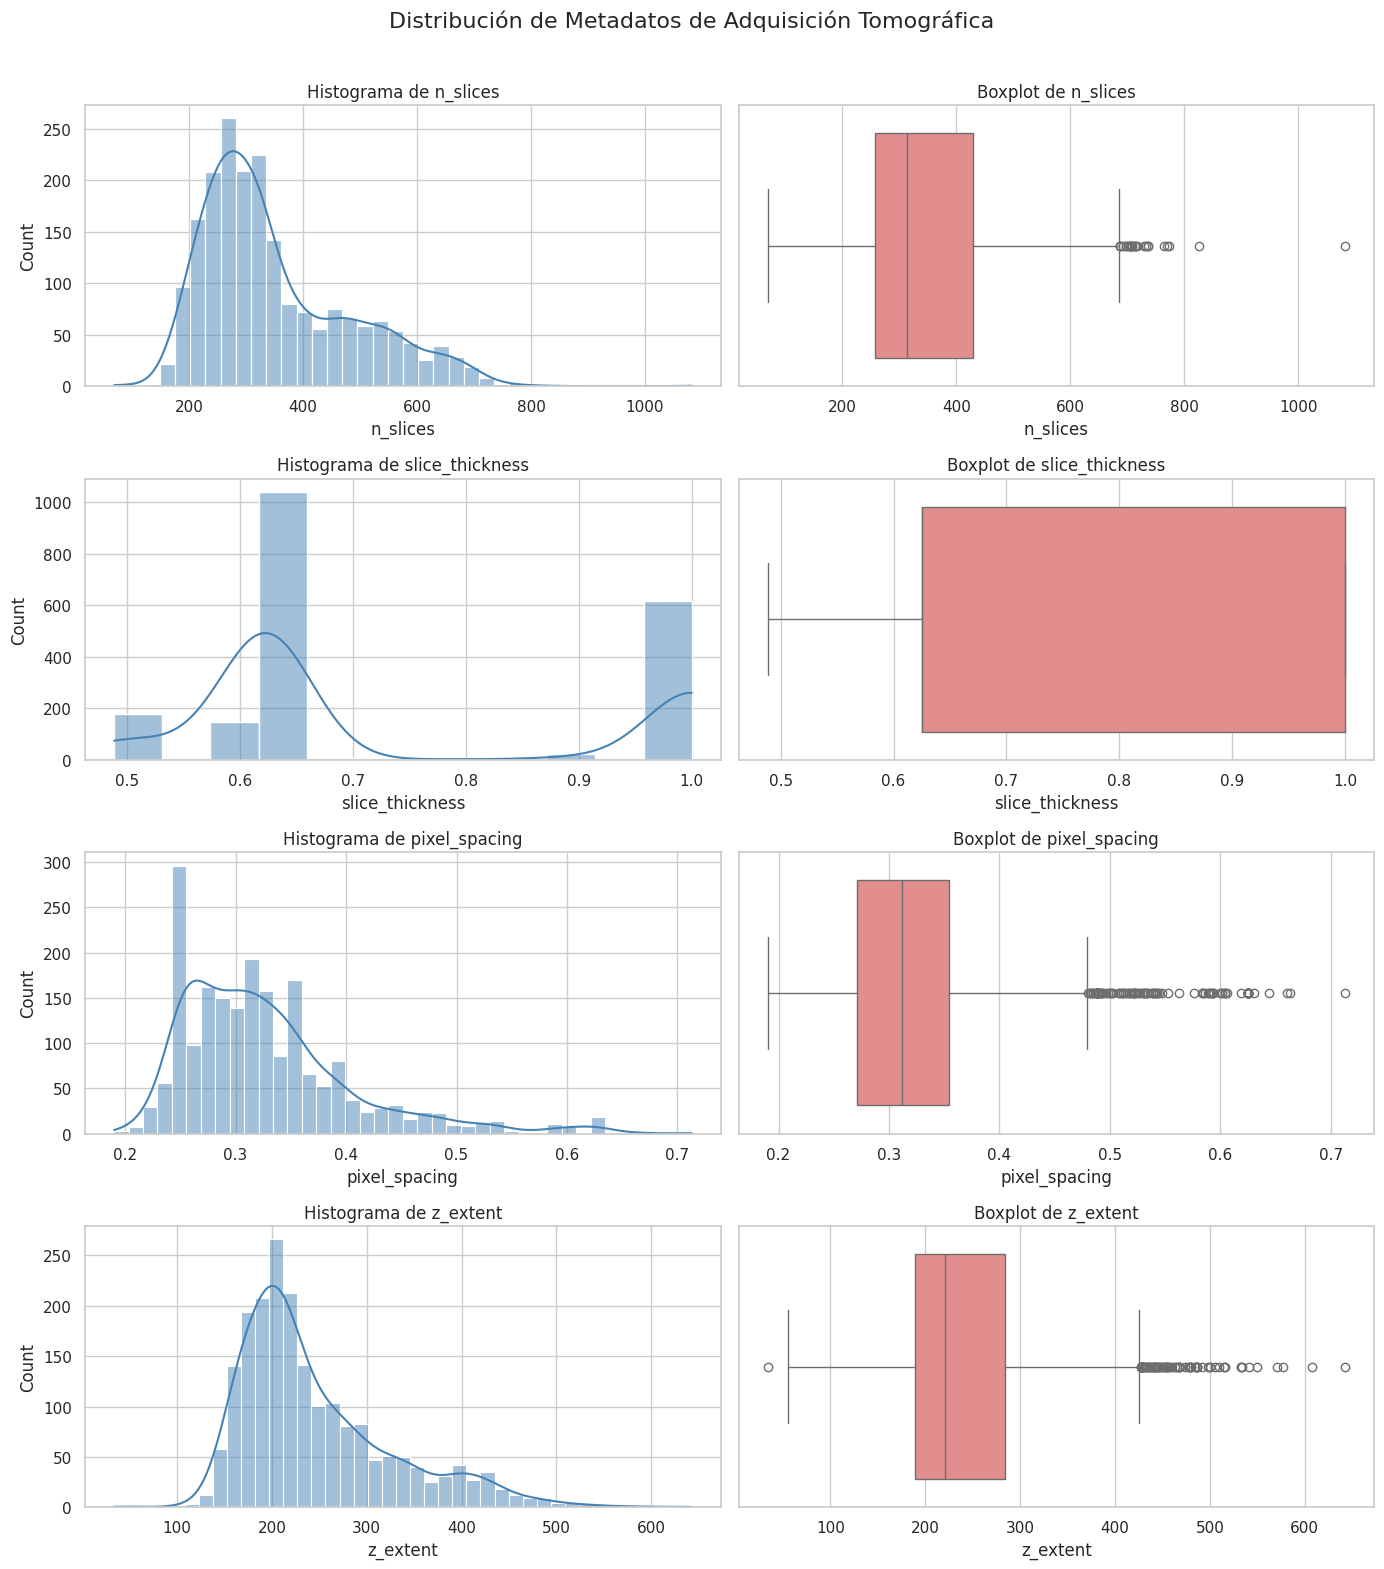

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Distribución de Metadatos de Adquisición Tomográfica', fontsize=16)

for i, col in enumerate(numeric_cols):
    # Histograma
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histograma de {col}')
    
    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [6]:
print("--- CUANTIFICACIÓN DE OUTLIERS (MÉTODO IQR) ---")
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers
    print(f"{col}: {len(outliers)} outliers ({(len(outliers)/len(df))*100:.2f}%)")

print("\nInspección de casos extremos (Top 3 por n_slices):")
display(outliers_dict['n_slices'].sort_values(by='n_slices', ascending=False).head(3))

--- CUANTIFICACIÓN DE OUTLIERS (MÉTODO IQR) ---
n_slices: 27 outliers (1.34%)
slice_thickness: 0 outliers (0.00%)
pixel_spacing: 111 outliers (5.50%)
z_extent: 84 outliers (4.16%)

Inspección de casos extremos (Top 3 por n_slices):


,StudyInstanceUID,n_slices,slice_thickness,pixel_spacing,manufacturer,patient_sex,kernel,z_extent,patient_overall
1716,1.2.826.0.1.3680043.20756,1082,0.500,0.358000,Desconocido,Desconocido,Desconocido,541.000,0
837,1.2.826.0.1.3680043.20925,825,0.625,0.394531,Desconocido,Desconocido,Desconocido,515.625,1
1917,1.2.826.0.1.3680043.9336,773,0.500,0.328000,Desconocido,Desconocido,Desconocido,386.500,0


Se realiza un análisis de outliers mediante la definición de un rango intercuartilico. Para la variable n_slices se tienen 27 outliers, al ser menos de un 2% se podría intentar mantenerlos ya que esta no es una variable directa en sí que el modelo vaya a ver para identificar una fractura, solo se tiene más información. Ahora en lo que se refiere slice_thickness, no hay outliers. En lo que se refiere a pixel_spacing, hay 111 outliers que representa el 5.50% del dataset y con respecto a z_extent son 84 outliers los cuales representan el 4.16% del dataset, ahora bien se recomienda realizar una transformación logaritmica a estas variables ya que parece ser que su distribución empírica sigue una distribución log-normal. Esto podría ayudar a reducir los outliers ya que estos si podrían afectar las señales que detecta el modelo.

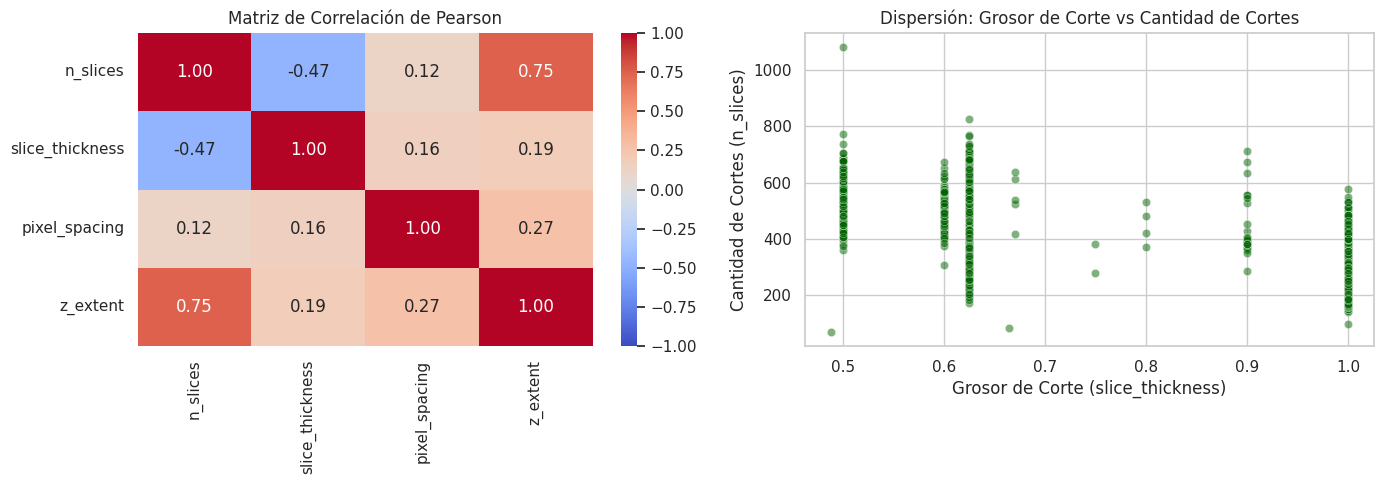

In [7]:
plt.figure(figsize=(14, 5))

# 1. Matriz de Correlación de Pearson
plt.subplot(1, 2, 1)
corr = df[numeric_cols].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación de Pearson')

# 2. Scatter plot: slice_thickness vs n_slices
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='slice_thickness', y='n_slices', alpha=0.5, color='darkgreen')
plt.title('Dispersión: Grosor de Corte vs Cantidad de Cortes')
plt.xlabel('Grosor de Corte (slice_thickness)')
plt.ylabel('Cantidad de Cortes (n_slices)')

plt.tight_layout()
plt.show()

En lo que se refiere al análisis de correlación (lineal) entre variables no se tiene una correlación alarmante (mayor a 0.85) por lo que no es necesaria ninguna eliminación de variable. Las correlaciones más altas (en magnitud) se dan entre n_slices y slice_thickness, lo cual es intuitivo ya que mientras más grosor fisico abarquen las imagenes, voy a necesitar menos para abarcar toda la columna cervical. El otro coeficiente alto entre variables se da entre n_slices y z_extent ya que mientras más grande sea una columna cervical se necesitaran mas scans o imagenes para abarcarla completamente.

In [8]:
print("--- FRECUENCIAS DE VARIABLES CATEGÓRICAS ---")
for col in categorical_cols:
    if col in df.columns:
        freq = pd.DataFrame({
            'Conteo': df[col].value_counts(dropna=False),
            'Porcentaje': df[col].value_counts(normalize=True, dropna=False) * 100
        })
        print(f"\n[{col.upper()}]")
        display(freq.round(2))

--- FRECUENCIAS DE VARIABLES CATEGÓRICAS ---

[MANUFACTURER]


,Conteo,Porcentaje
manufacturer,,
Desconocido,2019,100.0



[KERNEL]


,Conteo,Porcentaje
kernel,,
Desconocido,2019,100.0



[PATIENT_SEX]


,Conteo,Porcentaje
patient_sex,,
Desconocido,2019,100.0


Es importante notar que para las variables de manifacturer, kernel y patient_sex solo hay un valor y es desconocido, por lo que se recomienda eliminarlas ya que en si no agregan información para el modelo.

--- 1. TEST CHI-CUADRADO: Fabricante vs Fractura ---
Chi-cuadrado: 0.00 | p-valor: 1.0000e+00

--- 2. TEST MANN-WHITNEY U: Metadatos vs Fractura ---
n_slices        | U-Stat: 434736.0   | p-valor: 1.8187e-08 | ⚠️ Significativo
slice_thickness | U-Stat: 535032.5   | p-valor: 2.5565e-02 | ⚠️ Significativo
z_extent        | U-Stat: 428096.5   | p-valor: 8.4671e-10 | ⚠️ Significativo


/tmp/ipykernel_58/1353817611.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='patient_overall', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_58/1353817611.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='patient_overall', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_58/1353817611.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='patient_overall', y=col, ax=axes[i], palette='Set2')


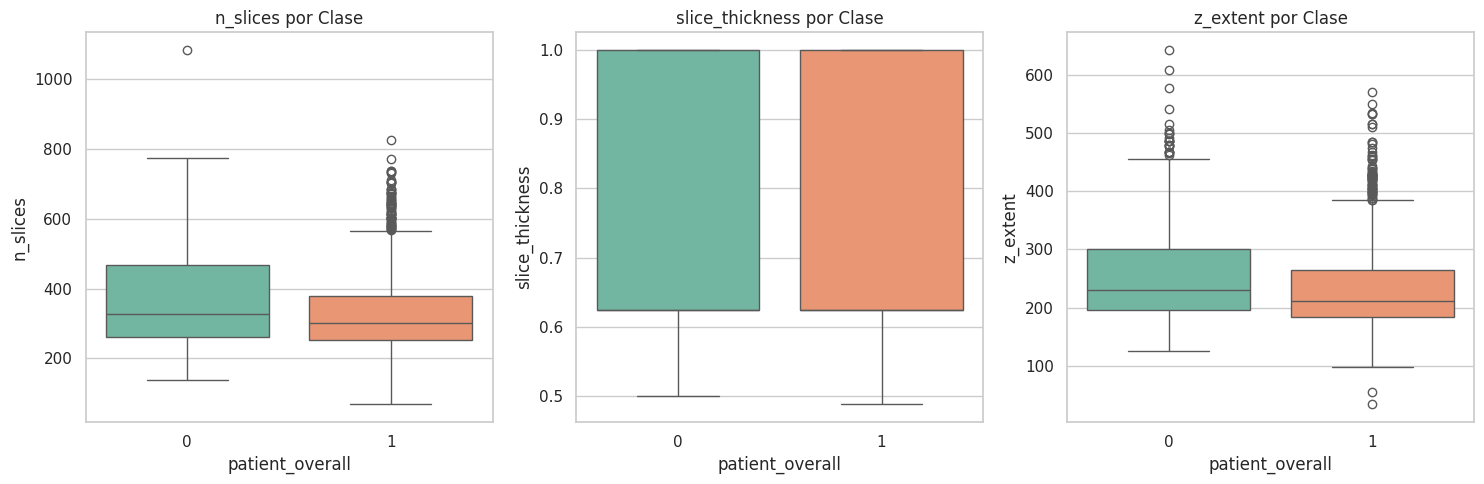

In [9]:
print("--- 1. TEST CHI-CUADRADO: Fabricante vs Fractura ---")
contingency_table = pd.crosstab(df['manufacturer'], df['patient_overall'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-cuadrado: {chi2:.2f} | p-valor: {p_val:.4e}")
if p_val < 0.05:
    print("⚠️ Resultado significativo: Existe asociación estadística entre el escáner y la presencia de fractura.")

print("\n--- 2. TEST MANN-WHITNEY U: Metadatos vs Fractura ---")
for col in ['n_slices', 'slice_thickness', 'z_extent']:
    pos = df[df['patient_overall'] == 1][col].dropna()
    neg = df[df['patient_overall'] == 0][col].dropna()
    
    stat, p = mannwhitneyu(pos, neg, alternative='two-sided')
    sig = "⚠️ Significativo" if p < 0.05 else "No significativo"
    print(f"{col:<15} | U-Stat: {stat:<10.1f} | p-valor: {p:.4e} | {sig}")

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['n_slices', 'slice_thickness', 'z_extent']):
    sns.boxplot(data=df, x='patient_overall', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} por Clase')
plt.tight_layout()
plt.show()

Mediante la prueba chi-cuadrado se determina que el fabricante (para este set de datos) no resulta significante para detectar una fractura, pero esto es consecuencia que se desconoce el fabricante para los scans de este dataset. 

Por otro lado, mediante una prueba no paramétrica de diferencia de medias se puede decir que existe una diferencia significativa entre los metadatos de espinas cervicales con y sin fracturas. 